# LoVoCCS 2D maps: Correlations between X-ray brightness and weak-lensing maps 

<span style="color:red">This section of the project investigates ...</span>

## Main takeaways 

In summary:

* We....

## Import Statements

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from matplotlib import pyplot as plt
import os
from astropy.units import Quantity
from astropy.visualization import LinearStretch, ImageNormalize, LogStretch, MinMaxInterval, SqrtStretch, AsinhStretch
from astropy.wcs import WCS
from astropy.io import fits
from shutil import rmtree
from fitsio import read
import umap
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from subprocess import Popen, PIPE

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '../')
from common import lovoccs_cosmo, haversine

import xga
# This just sets the number of cores this analysis is allowed to use
xga.NUM_CORES = 10
from xga import CENSUS
# This is a bodge that will only work because xga_output in notebooks has already been defined, XGA
#  will be made to handle this more gracefully at some point
temp_dir = xga.OUTPUT
actual_dir = temp_dir.split('notebooks/')[0]+'notebooks/xga_output/'
xga.OUTPUT = actual_dir
xga.utils.OUTPUT = actual_dir
# As currently XGA will setup an xga_output directory in our current directory, I remove it to keep it all clean
if os.path.exists('xga_output'):
    rmtree('xga_output')
from xga.samples import ClusterSample
from xga.products import Image, ExpMap, RateMap
from xga.imagetools.misc import pix_deg_scale

%matplotlib inline

## Useful values

Here we set up any values that are useful to several parts of the analysis in this notebook, and that we might wish to change in the future:

In [2]:
#

## Useful functions

Here we set up any functions used in this notebook:

In [3]:
def generate_wcs_matched_xmm_prod(src, lo_en, hi_en, wl_map):
    """
    This function replicates how XGA generates XMM images and exposure maps, and then how it combines them - this is 
    necessary because the stable version of XGA does not yet support generating images/exposure maps with custom binning.
    """
    def prep_cmd_inputs(evt):
        oi = evt.obs_id
        inst = evt.instrument
        
        with fits.open(evt.path) as fitso:
            xmm_det_deg_scale = fitso[0].header['REFYCDLT']
            
        xmm_binning = int(round(wl_map_pix_deg_scale / xmm_det_deg_scale, 0))

        if "pn" in inst:
            add_expr = "'#XMMEA_EP' && (PATTERN <= 4) && (FLAG .eq. 0)"
        else:
            add_expr = "'#XMMEA_EM' && (PATTERN <= 12) && (FLAG .eq. 0)"
            
        expr = " && ".join([e for e in ["expression='(PI in [{l}:{u}])".format(l=lo_chan, u=hi_chan), add_expr] if e != ""]) + "'"

        return oi, inst, xmm_binning, xmm_det_deg_scale, expr

    # The directory setup
    out_dir = os.path.join(xmm_rebinned_fits_path, src.name)
    os.makedirs(out_dir, exist_ok=True)
    
    wl_map_pix_deg_scale = wl_map.header['PC2_2']

    # Center to use for new images
    cent_coord = wl_map.coord_conv(Quantity([wl_map.shape[1]/2, wl_map.shape[0]/2], 'pix'), 'deg')
    1    # Need the CCF file for anything related to exposure maps, though not for images
    ccf_pth = "../xga_output/{oi}/ccf.cif"
    # Also attitude file
    att_pth = "../../../X-LoVoCCS-Data/data/archives/LoVoCCS/processed_data/xmm_pointed/{oi}/P{oi}OBX000ATTTSR0000.FIT"

    # In XMM detector coordinates, the lower and upper boundaries of the WL-WCS-matched images we're trying to make
    xmm_detcoord_bounds = [3649-263, 48885+263]

    add_expr = ""
    # The energy selection expression
    lo_chan = lo_en.to('eV').value.astype(int)
    hi_chan = hi_en.to('eV').value.astype(int)
        
    im_cmd = ("evselect table={e} imageset={i} xcolumn=X ycolumn=Y ximagebinsize={bs} "
              "yimagebinsize={bs} squarepixels=yes raimagecenter={ra_cen} decimagecenter={dec_cen} " 
              "ximagemin={l} ximagemax={u} withxranges=yes yimagemin={l} "
              "yimagemax={u} withyranges=yes {ex}")
    ex_cmd = ("export SAS_CCF={ccf}; eexpmap eventset={e} imageset={im} expimageset={eim} withdetcoords=no withvignetting=yes "
              "attitudeset={att} pimin={l} pimax={u}")
    mosaic_cmd = ("emosaic imagesets='{ims}' mosaicedset={mim}")

    #
    rel_census = CENSUS[CENSUS['ObsID'].isin(src.obs_ids)]
    rel_dists = haversine(src.ra_dec[0].value, src.ra_dec[1].value, rel_census['RA_PNT'].values, rel_census['DEC_PNT'].values)
    start_oi = rel_census['ObsID'].values[np.argmin(rel_dists)]

    start_evts = src.get_products('events', obs_id=start_oi)[0]
    # This is not my most elegant work, but never mind
    cur_oi, cur_inst, cur_binning, cur_xmm_det_scale, cur_expr = prep_cmd_inputs(start_evts)
    
    start_im_pth = os.path.join(out_dir, 'start_im-{l}_{u}keV.fits'.format(l=lo_en.value, u=hi_en.value))
    cur_im_cmd = im_cmd.format(e=start_evts.path, i=start_im_pth, bs=cur_binning, 
                               ra_cen=round(cent_coord[0].value, 12), dec_cen=round(cent_coord[1].value, 12),
                               l=xmm_detcoord_bounds[0], u=xmm_detcoord_bounds[1], ex=cur_expr)
    start_ex_pth = os.path.join(out_dir, 'start_ex-{l}_{u}keV.fits'.format(l=lo_en.value, u=hi_en.value))
    cur_ex_cmd = ex_cmd.format(ccf=ccf_pth.format(oi=cur_oi), e=start_evts.path, im=start_im_pth, 
                               eim=start_ex_pth, att=att_pth.format(oi=cur_oi), l=lo_chan, u=hi_chan)

    final_cmds = [cur_im_cmd, cur_ex_cmd]
    final_ims = [start_im_pth]
    final_exs = [start_ex_pth]
    
    oi_cents = {}
    for evt_list in src.get_products('events'):
        if (evt_list.obs_id == start_evts.obs_id) and (evt_list.instrument == start_evts.instrument):
            continue

        cur_oi, cur_inst, cur_binning, cur_xmm_det_scale, cur_expr = prep_cmd_inputs(evt_list)
        
        if cur_oi == start_oi:
            rel_cent = cent_coord
        elif cur_oi in oi_cents:
            rel_cent = oi_cents[cur_oi]
        else:
            rel_rel_census = rel_census[rel_census['ObsID'] == cur_oi]
            cur_oi_cent = Quantity(rel_rel_census[['RA_PNT', 'DEC_PNT']].values[0], 'deg')
            delta_coord = cur_oi_cent - cent_coord

            # An XMM detecter coordinate offset now
            delta_coord_det = (delta_coord.value / cur_xmm_det_scale)
            # Now we divide by our chosen binning, so that we assess how far away they are from one another 
            #  in terms of our detector coordinate binning
            delta_coord_det_binned = delta_coord_det / cur_binning
            # Now we'll use this to see how many detector-coord binnings (e.g. pixels of our final images) we 
            #  should offset the central coordinate of this observation from the original central coord
            off_signs = np.sign(delta_coord_det_binned)
            off_int = np.ceil(np.abs(delta_coord_det_binned))
            off_int = (off_int*off_signs).astype(int)

            rel_cent = cent_coord + Quantity(off_int*cur_binning*cur_xmm_det_scale, 'deg')
            oi_cents[cur_oi] = rel_cent

        # -{l}_{u}keV.fits'.format(l=lo_en.value, u=hi_en.value)
        cur_im_pth = os.path.join(out_dir, '{oi}-{i}-{l}_{u}keV-image.fits'.format(oi=cur_oi, i=cur_inst, 
                                                                                   l=lo_en.value, u=hi_en.value))
        cur_im_cmd = im_cmd.format(e=evt_list.path, i=cur_im_pth, bs=cur_binning, 
                                   ra_cen=round(rel_cent[0].value, 12), dec_cen=round(rel_cent[1].value, 12),
                                   l=xmm_detcoord_bounds[0], u=xmm_detcoord_bounds[1], ex=cur_expr)
        final_cmds.append(cur_im_cmd)
        final_ims.append(cur_im_pth)
        
        cur_ex_pth = os.path.join(out_dir, '{oi}-{i}-{l}_{u}keV-expmap.fits'.format(oi=cur_oi, i=cur_inst, 
                                                                                    l=lo_en.value, u=hi_en.value))
        cur_ex_cmd = ex_cmd.format(ccf=ccf_pth.format(oi=cur_oi), e=evt_list.path, im=cur_im_pth, 
                                   eim=cur_ex_pth, att=att_pth.format(oi=cur_oi), l=lo_chan, u=hi_chan)
        final_cmds.append(cur_ex_cmd)
        final_exs.append(cur_ex_pth)
    
    cur_mos_im = mosaic_cmd.format(ims=" ".join(final_ims), 
                                   mim=os.path.join(out_dir, "combined_image-{l}_{u}keV.fits".format(l=lo_en.value, u=hi_en.value)))
    final_cmds.append(cur_mos_im)
    
    cur_mos_ex = mosaic_cmd.format(ims=" ".join(final_exs), 
                                   mim=os.path.join(out_dir, "combined_expmap-{l}_{u}keV.fits".format(l=lo_en.value, u=hi_en.value)))
    final_cmds.append(cur_mos_ex)
    
    final_cmd = ";".join(final_cmds)

    return final_cmd

## Output paths

Paths to save comparison figures and any output results files - defined here to avoid repetition and make the code easier to read: 

In [4]:
# This directory will likely not be included in the GitHub repo, due to file sizes
xmm_rebinned_fits_path = "../../outputs/cluster_visualisations/xmm_wcs-matched_wlmap_fits/"
os.makedirs(xmm_rebinned_fits_path, exist_ok=True)

## Loading data files

Important considerations for this dataset:

* LoVoCCS produces aperture mass maps with a variety of smoothing scales applied, we have elected to use the maps at which the peak pixel has the highest E-mode SNR. **These aperture mass maps are not yet publicly available, so unfortunately this part of our analysis can not currently be reproduced by anyone running this notebook.**
* The aperture mass maps have a much worse angular resolution (~25 arcseconds) than XMM data, so we will need to create XMM count-rate maps with matching pixel sizes and locations.
* These particular mass maps were the product of the same processing used in the LoVoCCS-II ([Fu et al. 2024](https://ui.adsabs.harvard.edu/abs/2024ApJ...974...69F/abstract)) paper, though we are currently reprocessing much of the data with significantly upgraded software.

### X-LoVoCCS-I base sample

In [5]:
xlovoccs_base = pd.read_csv("../../sample_files/X-LoVoCCSI.csv")
xlovoccs_base.insert(0, 'name', xlovoccs_base['LoVoCCSID'].apply(lambda x: "LoVoCCS-" + str(x)))

xlovoccs_parent_base = xlovoccs_base.drop_duplicates('parent_LoVoCCSID')
xlovoccs_parent_base.head(6)

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4
0,LoVoCCS-1,1,1,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44
1,LoVoCCS-2,2,2,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44
2,LoVoCCS-4A,4A,4,A85North,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44
4,LoVoCCS-5,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44
5,LoVoCCS-7,7,7,A3827,330.480000,-59.950000,0.0980,1.1367,330.48000,-59.950000,NaN,NaN,4.204419e+44
6,LoVoCCS-9,9,9,A3266,67.830487,-61.447401,0.0589,1.1485,67.85000,-61.440000,67.830487,-61.447401,3.977333e+44


In [6]:
xlovoccs_parent_base = xlovoccs_parent_base[xlovoccs_parent_base['name'] != 'LoVoCCS-33'].reset_index(drop=True)

### LoVoCCS-II weak-lensing aperture mass maps

In [7]:
lovoccsII_wlapmass_inv = pd.read_csv("../../sample_files/aperture_mass_maps/inventory.csv")

multi_clust_map = lovoccsII_wlapmass_inv['name'].isna()
lovoccsII_wlapmass_inv_multi = lovoccsII_wlapmass_inv[multi_clust_map].reset_index(drop=True)
lovoccsII_wlapmass_inv = lovoccsII_wlapmass_inv[~multi_clust_map].reset_index(drop=True)

lovoccsII_wlapmass_inv['LoVoCCSID'] = lovoccsII_wlapmass_inv['name'].apply(lambda x: int(x.split('-')[-1]) if not pd.isnull(x) else np.NaN)
lovoccsII_wlapmass_inv.head(6)

,name,multi_name,file_name,LoVoCCSID
0,LoVoCCS-4,NaN,LoVoCCS-4_M_ap_SNR_b100_Rs15000_maybemaxsnr.fits,4
1,LoVoCCS-5,NaN,LoVoCCS-5_M_ap_SNR_b100_Rs14000_maxEsnr.fits,5
2,LoVoCCS-9,NaN,LoVoCCS-9_M_ap_SNR_b100_Rs13000_maxEsnr.fits,9
3,LoVoCCS-10,NaN,LoVoCCS-10_M_ap_SNR_b100_Rs12000_maxEsnr.fits,10
4,LoVoCCS-11,NaN,LoVoCCS-11_M_ap_SNR_b100_Rs14000_maxEsnr.fits,11
5,LoVoCCS-12,NaN,LoVoCCS-12_M_ap_SNR_b100_Rs11000_maxEsnr.fits,12


In [8]:
lovoccsII_wlapmass_inv_multi

,name,multi_name,file_name
0,NaN,LoVoCCS-1-90,LoVoCCS-1-90_M_ap_SNR_b100_Rs15000_maxEsnr.fits
1,NaN,LoVoCCS-2-14,LoVoCCS-2-14_M_ap_SNR_b100_Rs7000_maxEsnr.fits
2,NaN,LoVoCCS-7-134,LoVoCCS-7-134_M_ap_SNR_b100_Rs3000_maxEsnr.fits
3,NaN,LoVoCCS-76-89,LoVoCCS-76-89_M_ap_SNR_b100_Rs6000_maxEsnr.fits


### Combining tables

In [9]:
xlovoccs_samp = pd.merge(xlovoccs_parent_base, lovoccsII_wlapmass_inv, left_on='parent_LoVoCCSID', right_on='LoVoCCSID', 
                         how='inner', suffixes=('', '_inv'))
xlovoccs_samp['parent_name'] = xlovoccs_samp['parent_LoVoCCSID'].apply(lambda x: "LoVoCCS-" + str(x))
xlovoccs_samp.head(6)

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4,name_inv,multi_name,file_name,LoVoCCSID_inv,parent_name
0,LoVoCCS-4A,4A,4,A85North,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44,LoVoCCS-4,NaN,LoVoCCS-4_M_ap_SNR_b100_Rs15000_maybemaxsnr.fits,4,LoVoCCS-4
1,LoVoCCS-5,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44,LoVoCCS-5,NaN,LoVoCCS-5_M_ap_SNR_b100_Rs14000_maxEsnr.fits,5,LoVoCCS-5
2,LoVoCCS-9,9,9,A3266,67.830487,-61.447401,0.0589,1.1485,67.85000,-61.440000,67.830487,-61.447401,3.977333e+44,LoVoCCS-9,NaN,LoVoCCS-9_M_ap_SNR_b100_Rs13000_maxEsnr.fits,9,LoVoCCS-9
3,LoVoCCS-10,10,10,A1651,194.840000,-4.190000,0.0845,1.1252,194.84000,-4.190000,NaN,NaN,3.853573e+44,LoVoCCS-10,NaN,LoVoCCS-10_M_ap_SNR_b100_Rs12000_maxEsnr.fits,10,LoVoCCS-10
4,LoVoCCS-11,11,11,A754,137.280000,-9.670000,0.0542,1.1439,137.28000,-9.670000,NaN,NaN,3.849660e+44,LoVoCCS-11,NaN,LoVoCCS-11_M_ap_SNR_b100_Rs14000_maxEsnr.fits,11,LoVoCCS-11
5,LoVoCCS-12,12,12,A3571,206.870000,-32.850000,0.0391,1.1514,206.87000,-32.850000,NaN,NaN,3.819920e+44,LoVoCCS-12,NaN,LoVoCCS-12_M_ap_SNR_b100_Rs11000_maxEsnr.fits,12,LoVoCCS-12


## Loading LoVoCCS 2D weak-lensing SNR maps

In [10]:
single_cluster_maps = {}
for row_ind, row in xlovoccs_samp.iterrows():
    cur_file = os.path.join("../../sample_files/aperture_mass_maps/", row['file_name'])
    wl_snr_map = Image(cur_file, '', '', '', '', '', Quantity(0.0, 'keV'), Quantity(0.0, 'keV'))
    
    wl_snr_map_hdr = wl_snr_map.header
    
    wl_snr_map_w = WCS(naxis=2)
    key = ''
    wl_snr_map_w.wcs.crpix = [wl_snr_map_hdr["CRPIX1{}".format(key)], wl_snr_map_hdr["CRPIX2{}".format(key)]]
    wl_snr_map_w.wcs.cdelt = [wl_snr_map_hdr["PC1_1{}".format(key)], wl_snr_map_hdr["PC2_2{}".format(key)]]
    wl_snr_map_w.wcs.crval = [wl_snr_map_hdr["CRVAL1{}".format(key)], wl_snr_map_hdr["CRVAL2{}".format(key)]]
    wl_snr_map_w.wcs.ctype = [wl_snr_map_hdr["CTYPE1{}".format(key)], wl_snr_map_hdr["CTYPE2{}".format(key)]]
    
    wl_snr_map._wcs_radec = wl_snr_map_w
    
    wl_snr_map._data = read(wl_snr_map.path).astype("float64")
    wl_snr_map._shape = wl_snr_map.data.shape

    rel_name = row['parent_name']
    wl_snr_map.src_name = rel_name
    single_cluster_maps[rel_name] = wl_snr_map

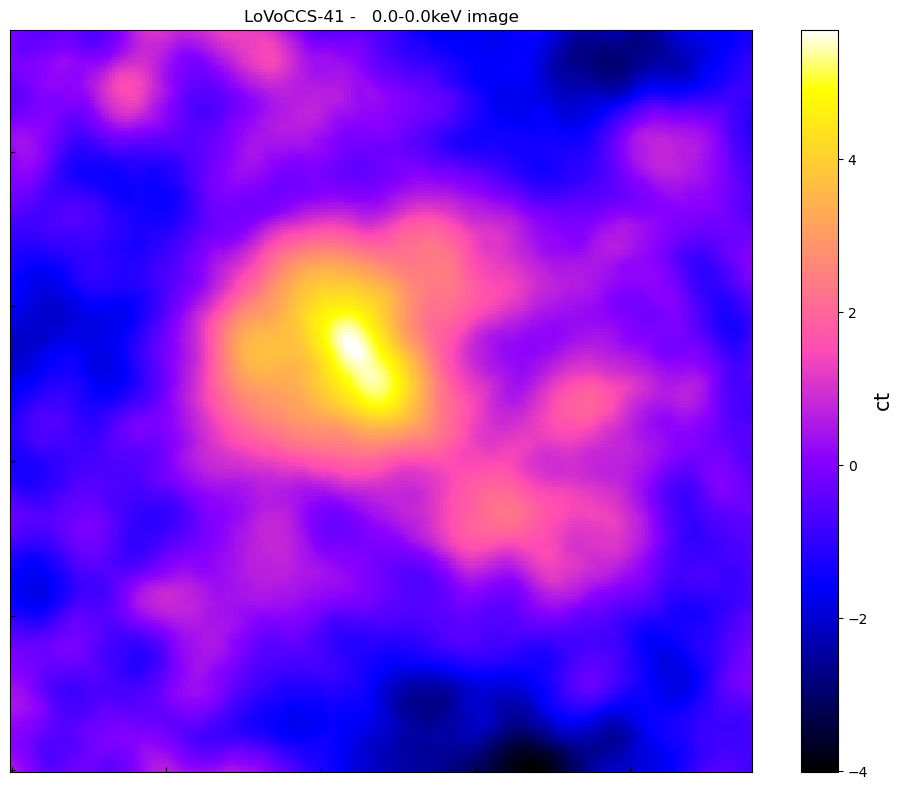

In [11]:
single_cluster_maps['LoVoCCS-41'].view(stretch=LinearStretch())

## Defining an XGA ClusterSample

In [ ]:
srcs = ClusterSample(xlovoccs_samp['start_ra'].values, xlovoccs_samp['start_dec'].values, xlovoccs_samp['MCXC_Redshift'].values, 
                     xlovoccs_samp['parent_name'].values, r500=Quantity(xlovoccs_samp['MCXC_R500'].values, 'Mpc'), use_peak=False, 
                     clean_obs=False, cosmology=lovoccs_cosmo)
srcs.info()

Setting up Galaxy Clusters:   9%|▊         | 4/46 [00:42<06:47,  9.69s/it]

## Generating and loading XMM count-rate maps matching WL map WCS

In [ ]:
gen_dir = "../../outputs/cluster_visualisations/xmm_wcs-matched_wlmap_fits/{n}/"
gen_lo_en = Quantity(0.5, 'keV')
gen_hi_en = Quantity(2.0, 'keV')

wcs_match_xmm_rts = {}
with tqdm(desc="Generating aperture-mass-map-WCS matched XMM ratemaps", total=len(srcs)) as onwards:
    for src in srcs:
        cur_name = src.name
        cur_row = xlovoccs_samp[xlovoccs_samp['parent_name'] == cur_name]
        
        cur_wl_map = single_cluster_maps[cur_name]
        cur_cmd = generate_wcs_matched_xmm_prod(src, gen_lo_en, gen_hi_en, cur_wl_map)

        cur_final_im_path = gen_dir.format(n=cur_name) + "combined_image-{l}_{u}keV.fits".format(l=gen_lo_en.value, 
                                                                                                 u=gen_hi_en.value)
        cur_final_ex_path = gen_dir.format(n=cur_name) + "combined_expmap-{l}_{u}keV.fits".format(l=gen_lo_en.value, 
                                                                                                  u=gen_hi_en.value)

        if not os.path.exists(cur_final_im_path):
            out, err = Popen(cur_cmd, shell=True, stdout=PIPE, stderr=PIPE).communicate()
            out = out.decode("UTF-8", errors='ignore')
            err = err.decode("UTF-8", errors='ignore')

        # Loading them in via XGA classes, for convenience
        cur_wcs_matched_im = Image(cur_final_im_path, "combined", "combined", '', '', '', gen_lo_en, gen_hi_en)
        cur_wcs_matched_im.src_name = cur_name
        cur_wcs_matched_ex = ExpMap(cur_final_ex_path, "combined", "combined", '', '', '', gen_lo_en, gen_hi_en)
        cur_wcs_matched_ex.src_name = cur_name
        
        # Setting up and storing an XGA ratemap
        wcs_match_xmm_rts[cur_name] = RateMap(cur_wcs_matched_im, cur_wcs_matched_ex)
        
        onwards.update(1)

## Calculating pixel offsets and shifting XMM ratemaps to exactly match WL aperture mass maps

In [ ]:
pix_for_pix_match_xmm_rt_arrs = {}
for cur_name, cur_rt in wcs_match_xmm_rts.items():
    cur_wl_map = single_cluster_maps[cur_name]

    pad_xray_rt = np.zeros(cur_wl_map.shape)

    # Numpy array pixel coordinates
    wl_zero = np.array(cur_wl_map.radec_wcs.all_pix2world(*[0, 0], 0))
    # The numpy-convention (i.e. starts at zero) coordinates
    padding_offset = np.array(pad_xray_rt.radec_wcs.all_world2pix(*wl_zero, 0)).round().astype(int)*-1
    np_padding_offset = np.flip(padding_offset)

    # TODO THIS BIT WOULD PROBABLY FALL OVER IN THE CASE OF X-RAY DATA GOING OVER THE LEFT/BOTTOM EDGES OF THE WL MAP
    wl_offset_lims = np.array(wl_snr_map.shape)-np_padding_offset

    pad_xray_rt[np_padding_offset[0]:np_padding_offset[0]+cur_rt.shape[0], 
                np_padding_offset[1]:np_padding_offset[1]+cur_rt.shape[1]] = cur_rt.data
    
    pix_for_pix_match_xmm_rt_arrs[cur_name] = pad_xray_rt

In [ ]:
for cur_name, cur_rt_arr in pix_for_pix_match_xmm_rt_arrs.items():
    plt.figure(figsize=(8, 8))
    
    norm = ImageNormalize(cur_rt_arr, MinMaxInterval(), stretch=LogStretch())
    plt.imshow(cur_rt_arr, 'gnuplot2', norm, origin='lower')
    
    plt.show()
    plt.close('all')

In [ ]:
stop

In [ ]:
all_the_inds = np.indices(wl_snr_map.data.shape)
all_the_inds.shape

In [ ]:
arr_y, arr_x = np.ogrid[:wl_snr_map.data.shape[0], :wl_snr_map.data.shape[1]]

rec_x = arr_x - 125
rec_y = arr_y - 120
seps = np.sqrt(rec_x**2 + rec_y**2)

In [ ]:
plt.figure(figsize=(8.5, 5))

plt.scatter(wl_snr_map.data.flatten(), np.sqrt((pad_xray_im/pad_xray_ex).flatten()), marker='.', c=seps, 
            cmap='rainbow', norm='linear', vmin=0, vmax=30)

# wl_restrict = wl_snr_map.data[115:115+28, 125:125+28].flatten()
# x_restrict = (pad_xray_im/pad_xray_ex)[115:115+28, 125:125+28].flatten()

# plt.plot(wl_restrict, x_restrict, 'D', color='black', alpha=0.7)

plt.ylabel('XMM ct/s')
plt.xlabel('Aperture Mass SNR')

plt.xscale('symlog')
# plt.yscale('log')

plt.xlim(3, 10)
# plt.ylim(0.0025)
# plt.ylim(0.0, 0.03)
plt.ylim(0.0, 0.18)

plt.colorbar(label='Centre-ish separation [pix]')
plt.show()

In [ ]:
plt.figure(figsize=(8.5, 5))

plt.scatter(wl_snr_map.data.flatten(), (pad_xray_im/pad_xray_ex).flatten(), marker='.', c=seps, 
            cmap='rainbow', norm='linear', vmin=0, vmax=30)

# wl_restrict = wl_snr_map.data[115:115+28, 125:125+28].flatten()
# x_restrict = (pad_xray_im/pad_xray_ex)[115:115+28, 125:125+28].flatten()

# plt.plot(wl_restrict, x_restrict, 'D', color='black', alpha=0.7)

plt.ylabel('XMM ct/s')
plt.xlabel('Aperture Mass SNR')

plt.xscale('symlog')
# plt.yscale('log')

plt.xlim(3, 10)
# plt.ylim(0.0025)
plt.ylim(0.0, 0.03)
# plt.ylim(0.0, 0.18)

plt.colorbar(label='Centre-ish separation [pix]')
plt.show()

## Dimensionality reduction

In [ ]:
all_data = np.vstack([all_the_inds[0, :, :].flatten(), all_the_inds[1, :, :].flatten(), wl_snr_map.data.flatten(), 
                      (pad_xray_im/pad_xray_ex).flatten()]).T
ind_arr = np.arange(0, len(all_data))
xy_data = np.vstack([all_the_inds[0, :, :].flatten(), all_the_inds[1, :, :].flatten()]).T

# good_data_msk = (~np.isnan(all_data)).all(axis=1)*(all_data[:, -1] > 0.0025)
# good_data = all_data[good_data_msk]
# good_xy_arr = xy_data[good_data_msk]

all_data = np.vstack([wl_snr_map.data.flatten(), (pad_xray_im/pad_xray_ex).flatten()]).T
xy_data = np.vstack([all_the_inds[0, :, :].flatten(), all_the_inds[1, :, :].flatten()]).T
good_data_msk = (~np.isnan(all_data)).all(axis=1)*(all_data[:, -1] > 0.0025)
# good_data_msk = (~np.isnan(all_data)).all(axis=1)*(all_data[:, -1] > 0.0015)
good_data = all_data[good_data_msk]
good_ind_arr = ind_arr[good_data_msk]

scaled_data = StandardScaler().fit_transform(all_data[good_data_msk])

In [ ]:
umap_dim_red = umap.UMAP(random_state=907)
umap_reduced = umap_dim_red.fit_transform(scaled_data)

In [ ]:
plt.figure(figsize=(6, 6))

new_line_boi = lambda x: -2*x  -4

oth_new_line_boi = lambda x: -2*x+3

plt.plot(umap_reduced[:, 0], umap_reduced[:, 1], '.')
plt.plot(umap_reduced[:, 0], new_line_boi(umap_reduced[:, 0]))
plt.plot(umap_reduced[:, 0], oth_new_line_boi(umap_reduced[:, 0]))

plt.ylim(-5.5, 13)
plt.show()

In [ ]:
plt.figure(figsize=(8, 8))

norm = ImageNormalize((pad_xray_im/pad_xray_ex), MinMaxInterval(), stretch=LogStretch())
# plt.imshow((pad_xray_im/pad_xray_ex)[115:115+28, 125:125+28], 'gnuplot2', norm, origin='lower')
plt.imshow((pad_xray_im/pad_xray_ex), 'gnuplot2', norm, origin='lower')

# chos_data = good_data[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] < -4.8)]
# chos_ind = good_ind_arr[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] < -4.8)]
# plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='darkgoldenrod')

# chos_data = good_data[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] > -4.8)]
# chos_ind = good_ind_arr[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] > -4.8)]
# plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='firebrick')

# chos_data = good_data[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] > 5)]
# chos_ind = good_ind_arr[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] > 5)]
# plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='darkgoldenrod')

# chos_data = good_data[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] > -4.8)]
# chos_ind = good_ind_arr[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] > -4.8)]
# plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='firebrick')

chos_data = good_data[umap_reduced[:, 1] > 8]
chos_ind = good_ind_arr[umap_reduced[:, 1] > 8]
plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='lime')

chos_data = good_data[umap_reduced[:, 1] < new_line_boi(umap_reduced[:, 0])]
chos_ind = good_ind_arr[umap_reduced[:, 1] < new_line_boi(umap_reduced[:, 0])]
plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='darkgoldenrod')

chos_data = good_data[(umap_reduced[:, 0] > 0) & (umap_reduced[:, 0] < 7) & (umap_reduced[:, 1] > 0) & (umap_reduced[:, 1] < 5)]
chos_ind = good_ind_arr[(umap_reduced[:, 0] > 0) & (umap_reduced[:, 0] < 7) & (umap_reduced[:, 1] > 0) & (umap_reduced[:, 1] < 5)]
plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='plum')

chos_data = good_data[(umap_reduced[:, 0] > 0) & (umap_reduced[:, 0] < 7) & (umap_reduced[:, 1] > 5) & (umap_reduced[:, 1] < 8)]
chos_ind = good_ind_arr[(umap_reduced[:, 0] > 0) & (umap_reduced[:, 0] < 7) & (umap_reduced[:, 1] > 5) & (umap_reduced[:, 1] < 8)]
plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='firebrick')

chos_data = good_data[(umap_reduced[:, 1] < oth_new_line_boi(umap_reduced[:, 0])) & 
                      (umap_reduced[:, 1] > new_line_boi(umap_reduced[:, 0]))]
chos_ind = good_ind_arr[(umap_reduced[:, 1] < oth_new_line_boi(umap_reduced[:, 0])) & 
                        (umap_reduced[:, 1] > new_line_boi(umap_reduced[:, 0]))]
# plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='darkseagreen')

# chos_data = good_data[(umap_reduced[:, 0] > 7.5) & (umap_reduced[:, 1] < 1.5) & (umap_reduced[:, 1] > 0)]
# chos_ind = good_ind_arr[(umap_reduced[:, 0] > 7.5) & (umap_reduced[:, 1] < 1.5) & (umap_reduced[:, 1] > 0)]
# plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='lime')

# plt.axvline(157, color='white')
# plt.axhline(75, color='white')

plt.axvline(130, color='white')
plt.axhline(84, color='white')

plt.show()

In [ ]:
plt.figure(figsize=(8.5, 5))

plt.scatter(wl_snr_map.data.flatten(), np.sqrt(pad_xray_im/pad_xray_ex).flatten(), marker='.', c=seps, 
            cmap='rainbow', norm='linear', vmin=0, vmax=30)

# chos_ind = good_ind_arr[umap_reduced[:, 1] > 8]
# chos_ind = good_ind_arr[umap_reduced[:, 1] < new_line_boi(umap_reduced[:, 0])]
wl_restrict = wl_snr_map.data.flatten()[chos_ind]
x_restrict = np.sqrt(pad_xray_im/pad_xray_ex).flatten()[chos_ind]

plt.plot(wl_restrict, x_restrict, 'D', color='black', alpha=0.7)

plt.ylabel('XMM ct/s')
plt.xlabel('Aperture Mass SNR')

plt.xscale('symlog')
# plt.yscale('log')

plt.xlim(3, 10)
# plt.ylim(0.0025)
# plt.ylim(0.0, 0.03)
# plt.ylim(0.0, 0.005)
plt.ylim(0.0, 0.18)

plt.colorbar(label='Centre-ish separation [pix]')
plt.show()

In [ ]:
plt.figure(figsize=(8.5, 5))

plt.scatter(wl_snr_map.data.flatten(), (pad_xray_im/pad_xray_ex).flatten(), marker='.', c=seps, cmap='rainbow', norm='linear')

wl_restrict = wl_snr_map.data.flatten()[chos_ind]
x_restrict = (pad_xray_im/pad_xray_ex).flatten()[chos_ind]

plt.plot(wl_restrict, x_restrict, 'D', color='black', alpha=0.7)


plt.ylabel('XMM ct/s')
plt.xlabel('Aperture Mass SNR')

plt.xscale('symlog')
# plt.yscale('log')

plt.xlim(1, 7)
plt.ylim(0.0025)
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(8.5, 5))

plt.scatter(wl_snr_map.data.flatten(), (pad_xray_im/pad_xray_ex).flatten(), marker='.', c=seps, cmap='rainbow', norm='linear')

line_boi = lambda x: x*0.006 - 0.021

plt.plot(wl_snr_map.data.flatten(), line_boi(wl_snr_map.data.flatten()))

plt.ylabel('XMM ct/s')
plt.xlabel('Aperture Mass SNR')

# plt.xscale('symlog')
# plt.yscale('log')

plt.xlim(1, 7)
plt.ylim(0.0025)
plt.colorbar()
plt.show()

In [ ]:
lower_spike_inds = np.argwhere((pad_xray_im/pad_xray_ex).flatten() < line_boi(wl_snr_map.data.flatten())).flatten()

In [ ]:
all_data

In [ ]:
plt.figure(figsize=(8, 8))

norm = ImageNormalize((pad_xray_im/pad_xray_ex), MinMaxInterval(), stretch=LogStretch())
# plt.imshow((pad_xray_im/pad_xray_ex)[115:115+28, 125:125+28], 'gnuplot2', norm, origin='lower')
plt.imshow((pad_xray_im/pad_xray_ex), 'gnuplot2', norm, origin='lower')

plt.plot(all_data[lower_spike_inds, 1], all_data[lower_spike_inds, 0], 'x', color='darkgoldenrod')


plt.show()

Quick ratio

In [ ]:
plt.figure(figsize=(8, 8))

ratios = (pad_xray_im/pad_xray_ex) / wl_snr_map.data
norm = ImageNormalize(ratios, MinMaxInterval(), stretch=AsinhStretch())

plt.imshow(ratios, 'gnuplot2', norm, origin='lower')
plt.show()